# Steps:

### Import relevant Modules or Libraries

- **Basic EDA**
    - Statistical Analysis
    - Missing Values
    - Duplicate Values
    - Outliers/Anomalies Detection
    - Data Visualization
    - Feature Encoding
    - Multi-Colliniearity
    - Feature Selection
    
****

- **Model Building**
    - Separate Independent and Dependent data
    - Split data into training and test
    - Model Selection
    - Model Training
    - Model Prediction
    - Model Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Basic EDA

In [2]:
df = pd.read_csv('USA_Housing.csv')
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


# Statistical Analysis

In [3]:
df.shape

(5000, 7)

In [4]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


# Missing Values

In [7]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

# Duplicate Values

In [8]:
df.duplicated().sum()

0

In [9]:
df[df.duplicated()]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address


# Outliers/Anomalies Detection

## Using Boxplot

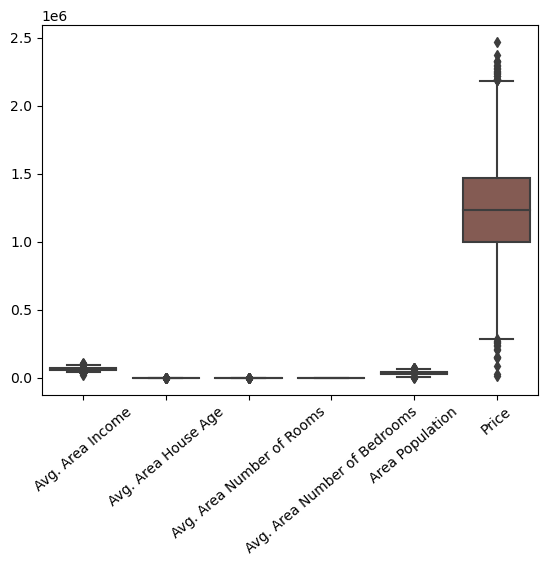

In [11]:
sns.boxplot(df)
plt.xticks(rotation=40)
plt.show()

In [12]:
for i in df.columns:
    if i == 'Address':
        pass
    else:
        print(i)

Avg. Area Income
Avg. Area House Age
Avg. Area Number of Rooms
Avg. Area Number of Bedrooms
Area Population
Price


Avg. Area Income


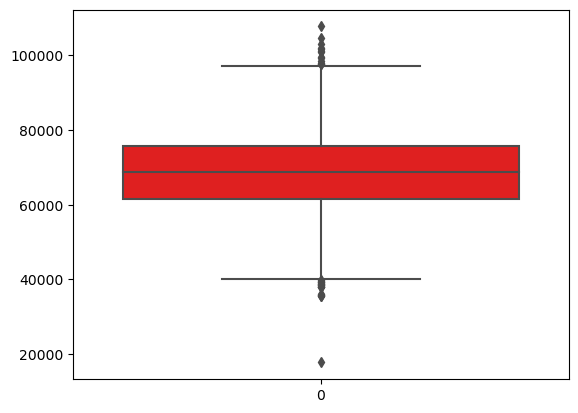

Avg. Area House Age


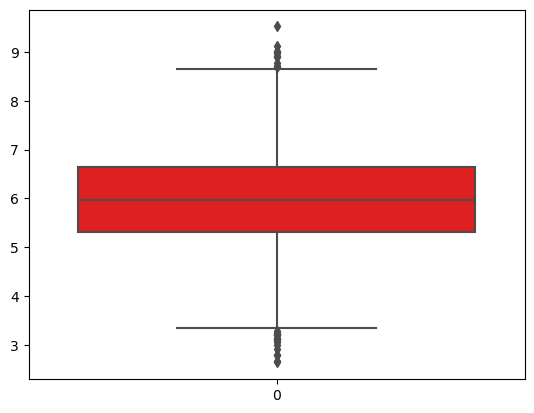

Avg. Area Number of Rooms


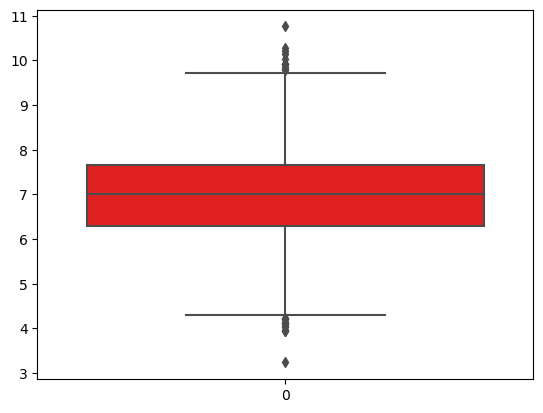

Avg. Area Number of Bedrooms


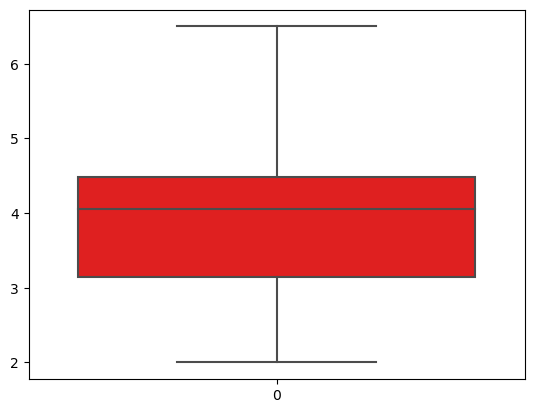

Area Population


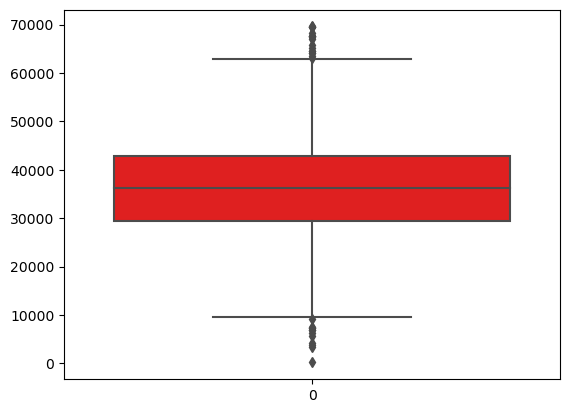

Price


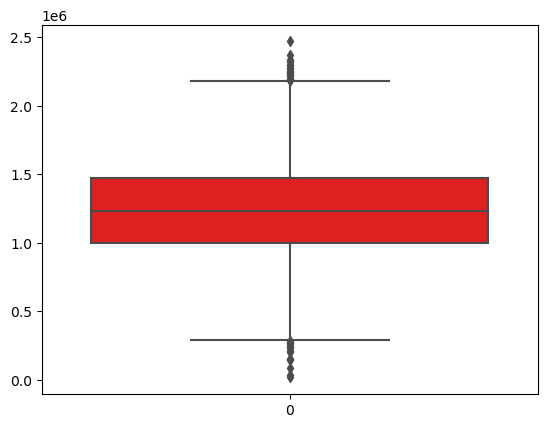

In [13]:
for i in df.columns:
    if i == 'Address':
        pass
    else:
        print(i)
        sns.boxplot(df[i], color='r')
        plt.show()

## Using IQR

In [14]:
Q1 = df.quantile(0.25)
Q1

Avg. Area Income                 61480.562388
Avg. Area House Age                  5.322283
Avg. Area Number of Rooms            6.299250
Avg. Area Number of Bedrooms         3.140000
Area Population                  29403.928702
Price                           997577.135049
Name: 0.25, dtype: float64

In [15]:
Q3 = df.quantile(0.75)
Q3

Avg. Area Income                7.578334e+04
Avg. Area House Age             6.650808e+00
Avg. Area Number of Rooms       7.665871e+00
Avg. Area Number of Bedrooms    4.490000e+00
Area Population                 4.286129e+04
Price                           1.471210e+06
Name: 0.75, dtype: float64

In [16]:
IQR = Q3 - Q1
IQR

Avg. Area Income                 14302.776278
Avg. Area House Age                  1.328525
Avg. Area Number of Rooms            1.366621
Avg. Area Number of Bedrooms         1.350000
Area Population                  13457.362067
Price                           473633.069163
dtype: float64

In [17]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

lower_bound

Avg. Area Income                 40026.397972
Avg. Area House Age                  3.329495
Avg. Area Number of Rooms            4.249318
Avg. Area Number of Bedrooms         1.115000
Area Population                   9217.885601
Price                           287127.531305
dtype: float64

In [18]:
upper_bound

Avg. Area Income                9.723750e+04
Avg. Area House Age             8.643597e+00
Avg. Area Number of Rooms       9.715803e+00
Avg. Area Number of Bedrooms    6.515000e+00
Area Population                 6.304733e+04
Price                           2.181660e+06
dtype: float64

In [19]:
df[((df < lower_bound) | (df > upper_bound)).any(axis=1)]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
12,39033.809237,7.671755,7.250029,3.10,39220.361467,1.042814e+06,"209 Natasha Stream Suite 961\nHuffmanland, NE ..."
28,90499.057451,6.384359,4.242191,3.04,33970.164990,1.240764e+06,"6531 Chase Prairie Apt. 245\nSusanshire, MN 22365"
39,17796.631190,4.949557,6.713905,2.50,47162.183643,3.023558e+05,"9932 Eric Circles\nLake Martha, WY 34611-6127"
90,48904.983269,4.844973,5.448956,3.38,32960.753070,2.018981e+05,"2124 Garcia Viaduct\nNorth Kellytown, DC 30864"
228,66574.709994,5.550265,6.844150,2.17,69575.449464,1.702406e+06,"551 Macdonald Viaduct\nWest Stephanie, TN 55360"
...,...,...,...,...,...,...,...
4803,61846.135900,5.057578,7.681141,3.39,69621.713378,1.504316e+06,"8500 Colin Shores Apt. 432\nNew Gilbert, FM 03165"
4844,37908.675863,6.233813,7.252916,6.07,39632.079786,8.804028e+05,"901 Peter Fort Apt. 157\nTaylorfort, ND 06249-..."
4855,35797.323122,5.544221,7.795138,5.00,24844.200190,2.998630e+05,"645 Mary Radial\nEast Roberto, CA 23652-5430"
4859,73685.403658,8.916093,6.291818,3.05,36000.506028,1.798927e+06,"7178 Michael Key Apt. 038\nMccallmouth, MS 378..."


In [20]:
df[((df < lower_bound) | (df > upper_bound)).any(axis=1)].index

Int64Index([  12,   28,   39,   90,  228,  256,  263,  314,  353,  355,
            ...
            4565, 4684, 4716, 4744, 4777, 4803, 4844, 4855, 4859, 4978],
           dtype='int64', length=135)

In [21]:
df.shape

(5000, 7)

In [22]:
5000-135

4865

In [23]:
df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [24]:
df = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

In [25]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


Avg. Area Income


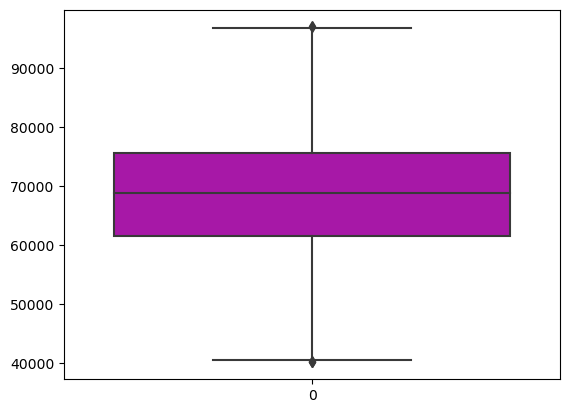

Avg. Area House Age


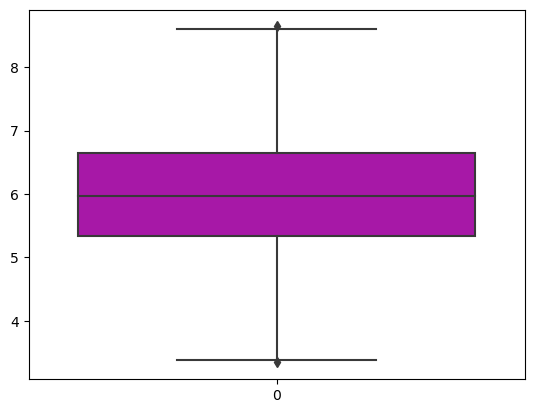

Avg. Area Number of Rooms


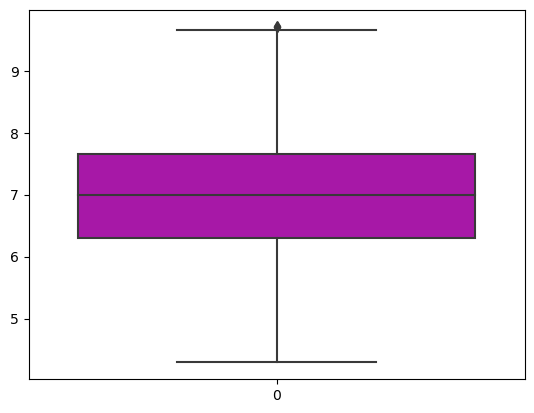

Avg. Area Number of Bedrooms


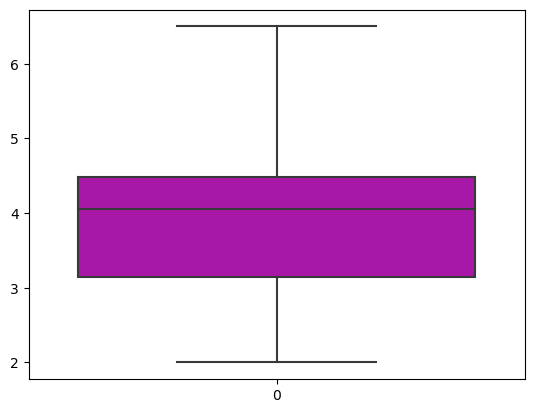

Area Population


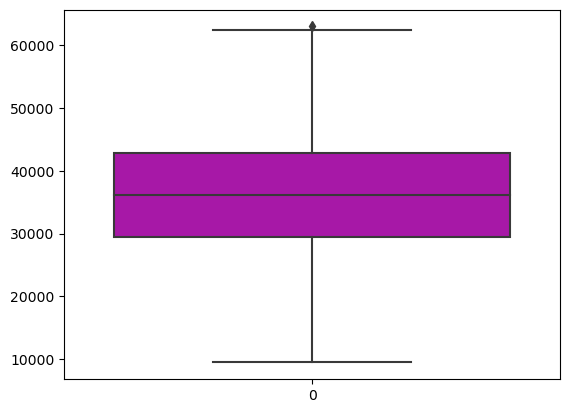

Price


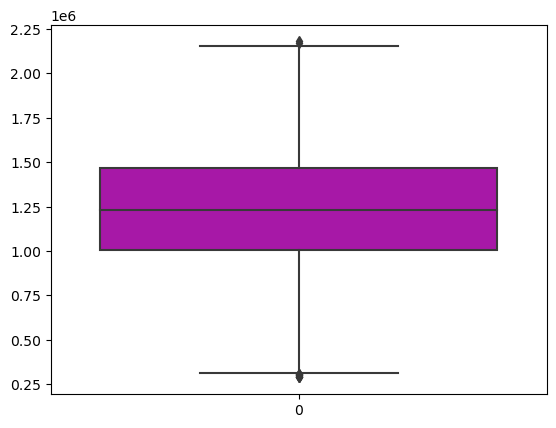

In [26]:
for i in df.columns:
    if i == 'Address':
        pass
    else:
        print(i)
        sns.boxplot(df[i], color='m')
        plt.show()

# Feature Encoding

In [27]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [28]:
df['Address']

0       208 Michael Ferry Apt. 674\nLaurabury, NE 3701...
1       188 Johnson Views Suite 079\nLake Kathleen, CA...
2       9127 Elizabeth Stravenue\nDanieltown, WI 06482...
3                               USS Barnett\nFPO AP 44820
4                              USNS Raymond\nFPO AE 09386
                              ...                        
4995                     USNS Williams\nFPO AP 30153-7653
4996                PSC 9258, Box 8489\nAPO AA 42991-3352
4997    4215 Tracy Garden Suite 076\nJoshualand, VA 01...
4998                            USS Wallace\nFPO AE 73316
4999    37778 George Ridges Apt. 509\nEast Holly, NV 2...
Name: Address, Length: 4865, dtype: object

In [29]:
df['Address'].value_counts()

208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101       1
481 Kaitlin Mission Apt. 309\nJodystad, IA 16947           1
0065 Samuel Common\nWest Barbara, SD 55041                 1
33897 David Avenue\nNicoleborough, AK 91150                1
PSC 2156, Box 9090\nAPO AE 71537                           1
                                                          ..
USNS Davis\nFPO AE 01516-7753                              1
4841 Gonzales Cliff\nJessicaton, ME 01252-0631             1
USNS Miller\nFPO AE 14408                                  1
974 Austin Loop Suite 256\nThorntonberg, NH 82286          1
37778 George Ridges Apt. 509\nEast Holly, NV 29290-3595    1
Name: Address, Length: 4865, dtype: int64

In [30]:
del df['Address']

In [31]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


# Multi-Colliniearity

In [32]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [33]:
d = df.drop(columns=['Price'], axis=1)
d

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [34]:
d.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
Avg. Area Income,1.000000,-0.021102,-0.021113,0.012875,-0.014097
Avg. Area House Age,-0.021102,1.000000,-0.016919,0.001177,-0.024151
Avg. Area Number of Rooms,-0.021113,-0.016919,1.000000,0.466596,-0.000244
Avg. Area Number of Bedrooms,0.012875,0.001177,0.466596,1.000000,-0.023172
Area Population,-0.014097,-0.024151,-0.000244,-0.023172,1.000000


<Axes: >

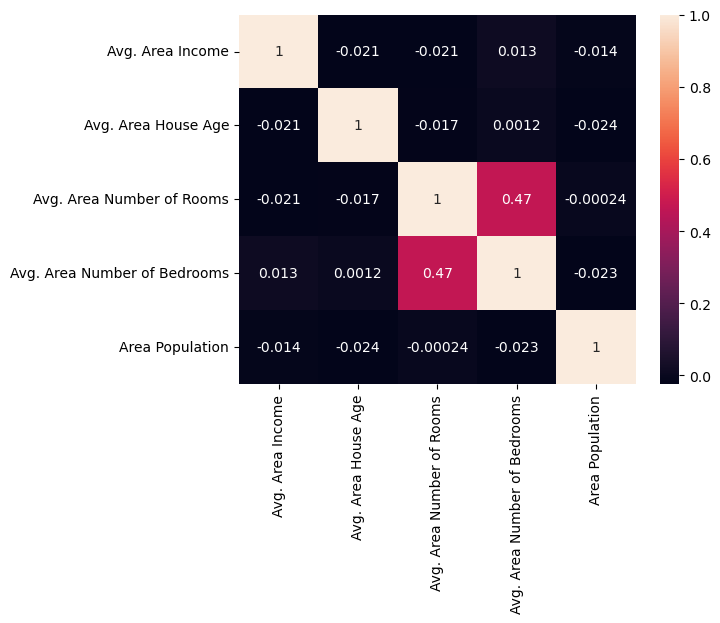

In [35]:
sns.heatmap(d.corr(), annot=True)

# Feature Selection

In [36]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


In [37]:
df.corr()['Price']

Avg. Area Income                0.632031
Avg. Area House Age             0.441675
Avg. Area Number of Rooms       0.329630
Avg. Area Number of Bedrooms    0.168606
Area Population                 0.406027
Price                           1.000000
Name: Price, dtype: float64

# Model Building

In [38]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


# Separate Independent and Dependent data

In [39]:
X = df.drop(columns=['Price'], axis=1)
y = df['Price']

In [40]:
X

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [41]:
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 4865, dtype: float64

# Split data into training and test

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
X_train

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2363,69266.087427,5.891946,7.148314,3.40,37180.500359
1887,60812.864534,7.157499,6.276444,2.22,26411.142277
3633,69206.554811,7.465323,7.624139,6.39,27666.403599
184,82906.654801,5.901452,5.767366,4.26,38820.481944
4526,69664.075765,7.612180,5.945619,2.00,37012.993434
...,...,...,...,...,...
4551,79500.398946,8.554884,6.160048,3.29,32069.117413
478,62685.270752,6.057649,6.766130,2.17,42018.938568
3185,66469.369473,4.663863,6.117542,4.13,22670.608616
3881,59084.725195,7.086564,6.144059,2.11,42955.908360


In [45]:
X_test

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2250,80431.035597,5.474911,6.322611,4.05,34615.598486
4583,62654.359483,5.674788,6.850386,4.24,36718.512313
2729,66300.581924,6.114219,5.588031,4.22,31581.838516
2166,65013.212446,7.321305,7.591328,3.13,23039.889474
4874,67794.294771,8.104891,6.211783,2.45,25903.809477
...,...,...,...,...,...
1520,69882.273926,5.646558,5.647646,4.35,19544.751964
2610,55421.168887,8.223912,7.526952,3.07,30995.209936
2089,77033.913592,4.079782,8.441009,6.26,26160.161047
2331,79817.665761,6.019475,8.073787,5.41,31765.901385


In [46]:
y_train

2363    1.107160e+06
1887    9.782413e+05
3633    1.404036e+06
184     1.454943e+06
4526    1.074647e+06
            ...     
4551    1.727983e+06
478     1.025461e+06
3185    4.122692e+05
3881    1.073254e+06
880     1.967637e+06
Name: Price, Length: 3892, dtype: float64

In [47]:
y_test

2250    1.300479e+06
4583    1.053485e+06
2729    1.009769e+06
2166    1.131041e+06
4874    1.343395e+06
            ...     
1520    7.268839e+05
2610    1.403176e+06
2089    1.025418e+06
2331    1.428399e+06
4275    1.754866e+06
Name: Price, Length: 973, dtype: float64

In [48]:
X_train.shape, X_test.shape

((3892, 5), (973, 5))

In [49]:
y_train.shape, y_test.shape

((3892,), (973,))

# Model Selection

## Using Linear Regression

In [50]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [51]:
lr.score(X_train, y_train)

0.911537564238988

In [52]:
lr.score(X_test, y_test)

0.9126986629438489

In [53]:
print(f'Training Accuracy : {round(lr.score(X_train, y_train), 2)*100}%')
print(f'Test Accuracy     : {round(lr.score(X_test, y_test), 2)*100}%')

Training Accuracy : 91.0%
Test Accuracy     : 91.0%


## Using KNN Algo

In [54]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=7)

In [55]:
print(f'Training Accuracy : {round(knn.score(X_train, y_train), 2)*100}%')
print(f'Test Accuracy     : {round(knn.score(X_test, y_test), 2)*100}%')

Training Accuracy : 64.0%
Test Accuracy     : 50.0%


## Using Decision Tree

In [65]:
dtree = DecisionTreeRegressor(max_depth=9)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=9)

In [66]:
print(f'Training Accuracy : {round(dtree.score(X_train, y_train), 2)*100}%')
print(f'Test Accuracy     : {round(dtree.score(X_test, y_test), 2)*100}%')

Training Accuracy : 92.0%
Test Accuracy     : 78.0%


# Model Training - Linear Regression

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [68]:
lr.coef_

array([2.15590620e+01, 1.65958273e+05, 1.19758233e+05, 1.06755714e+03,
       1.49866650e+01])

In [69]:
X.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population'],
      dtype='object')

In [70]:
pd.DataFrame(lr.coef_, index=X.columns, columns=['Coefficients/Weights'])

,Coefficients/Weights
Avg. Area Income,21.559062
Avg. Area House Age,165958.272744
Avg. Area Number of Rooms,119758.232952
Avg. Area Number of Bedrooms,1067.557140
Area Population,14.986665


# Model Prediction

In [71]:
lr

LinearRegression()

In [72]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

In [73]:
X_train[:3]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2363,69266.087427,5.891946,7.148314,3.40,37180.500359
1887,60812.864534,7.157499,6.276444,2.22,26411.142277
3633,69206.554811,7.465323,7.624139,6.39,27666.403599


In [74]:
y_train[:3]

2363    1.107160e+06
1887    9.782413e+05
3633    1.404036e+06
Name: Price, dtype: float64

In [75]:
y_pred_train[:3]

array([1266013.93072291, 1026729.25636162, 1443436.66594478])

In [76]:
X_test[:3]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2250,80431.035597,5.474911,6.322611,4.05,34615.598486
4583,62654.359483,5.674788,6.850386,4.24,36718.512313
2729,66300.581924,6.114219,5.588031,4.22,31581.838516


In [77]:
y_test[:3]

2250    1.300479e+06
4583    1.053485e+06
2729    1.009769e+06
Name: Price, dtype: float64

In [78]:
y_pred_test[:3]

array([1300879.08720861, 1045725.77688449,  969081.69718645])

# Model Evaluation

In [79]:
# Training Evaluation

def training_evaluation(actual, predicted):
    
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))    
    mae = mean_absolute_error(actual, predicted)    
    r2 = r2_score(actual, predicted)    
    
    print(f'MSE      : {mse}')
    print(f'RMSE     : {rmse}')    
    print(f'MAE      : {mae}')    
    print(f'R2_Score : {r2}')    
    print()
    
    plt.scatter(actual, predicted, color='r', label='Actual Price')
    plt.plot([actual.min(), actual.max()], [predicted.min(), predicted.max()], color='k', lw=3, label='Predicted Price')
    plt.title('Best Fit Line - Training Data')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.show()

MSE      : 10083105986.347572
RMSE     : 100414.67017496782
MAE      : 80921.16373101527
R2_Score : 0.911537564238988



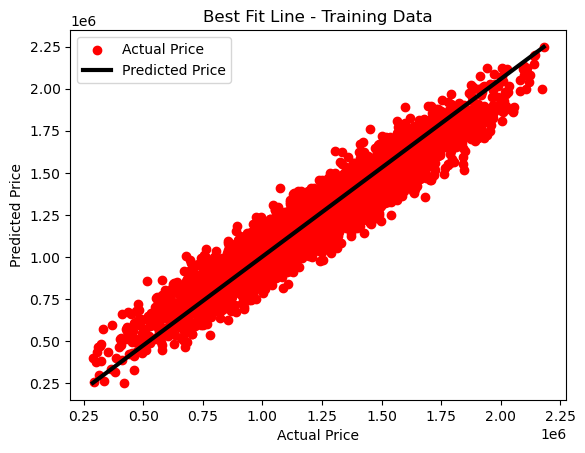

In [80]:
training_evaluation(y_train, y_pred_train)

In [81]:
# Test Evaluation

def test_evaluation(actual, predicted):
    
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))    
    mae = mean_absolute_error(actual, predicted)    
    r2 = r2_score(actual, predicted)    
    
    print(f'MSE      : {mse}')
    print(f'RMSE     : {rmse}')    
    print(f'MAE      : {mae}')    
    print(f'R2_Score : {r2}')    
    print()
    
    plt.scatter(actual, predicted, color='g', label='Actual Price')
    plt.plot([actual.min(), actual.max()], [predicted.min(), predicted.max()], color='k', lw=3, label='Predicted Price')
    plt.title('Best Fit Line - Test Data')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.show()

MSE      : 10295321311.369009
RMSE     : 101465.8627882748
MAE      : 81137.45704516846
R2_Score : 0.9126986629438489



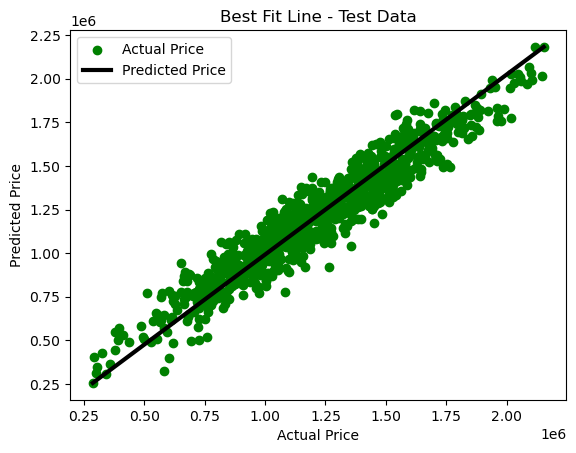

In [82]:
test_evaluation(y_test, y_pred_test)